# Tourist Attraction Recommendation

## Installation and imports


In [ ]:
!pip -q install haversine sentence-transformers

import json
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haversine import haversine, Unit
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_SEED = 42
N_EVAL_QUERIES = 50
RELEVANCE_MIN = 0.70
RELEVANCE_MAX = 0.98

print('Dependencies imported successfully.')


Dependencies imported successfully.


## Data preprocessing and feature construction

This section performs data cleaning, valid-rating handling, RobustScaler transformation, metadata extraction, Multilingual SBERT encoding, and construction of the fused destination representation.


## 1. Data cleaning and missing-rating handling


In [ ]:
# LOAD & CLEAN DATA
df_raw = pd.read_csv('Tourism_Data.csv')
raw_count = len(df_raw)

# Duplicate-title removal
df_after_dedup = df_raw.drop_duplicates(subset=['title']).copy()
duplicate_title_rows_removed = raw_count - len(df_after_dedup)

# Remove records without usable coordinates
df = df_after_dedup.dropna(subset=['latitude', 'longitude']).copy()
coordinate_rows_removed = len(df_after_dedup) - len(df)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.dropna(subset=['latitude', 'longitude']).copy()

df['title'] = df['title'].fillna('').astype(str)
df['category'] = df['category'].fillna('').astype(str)

# Reviewer correction: Google Maps ratings are valid in the 1–5 range.
# 0 and other out-of-range/unparseable values are treated as missing.
df['rating_raw_numeric'] = pd.to_numeric(df['review_rating'], errors='coerce')
invalid_or_missing_rating = ~df['rating_raw_numeric'].between(1, 5)
n_missing_rating = int(invalid_or_missing_rating.sum())
df.loc[invalid_or_missing_rating, 'rating_raw_numeric'] = np.nan

valid_rating_mode = df['rating_raw_numeric'].mode(dropna=True)
if valid_rating_mode.empty:
    raise ValueError('No valid 1–5 ratings are available for imputation.')

rating_imputation_value = float(valid_rating_mode.iloc[0])
df['rating_num'] = df['rating_raw_numeric'].fillna(rating_imputation_value)

df = df.reset_index(drop=True)

print('=== CLEANING SUMMARY ===')
print(f'Raw rows                         : {raw_count}')
print(f'Duplicate-title rows removed    : {duplicate_title_rows_removed}')
print(f'Rows without usable coordinates : {coordinate_rows_removed}')
print(f'Final rows                       : {len(df)}')
print(f'Missing/invalid ratings imputed : {n_missing_rating}')
print(f'Rating imputation value (mode)  : {rating_imputation_value:.2f}')
print(f"Valid rating range after handling: {df['rating_num'].min():.2f} to {df['rating_num'].max():.2f}")


=== CLEANING SUMMARY ===
Raw rows                         : 5618
Duplicate-title rows removed    : 109
Rows without usable coordinates : 0
Final rows                       : 5509
Missing/invalid ratings imputed : 117
Rating imputation value (mode)  : 4.50
Valid rating range after handling: 1.00 to 5.00


### RobustScaler normalization

Latitude, longitude, and the cleaned rating variable are transformed with RobustScaler. The paper should report statistics from this post-imputation pipeline, not from an intermediate representation where missing ratings were encoded as zero.


In [ ]:
# ROBUST-SCALER TABLE FOR PAPER
numerical_features = ['latitude', 'longitude', 'rating_num']

robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(df[numerical_features])
scaled_cols = [f'robust_scaled_{c}' for c in numerical_features]
df[scaled_cols] = robust_scaled

paper_stats = df[scaled_cols].describe().loc[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(3)

print('=== PAPER TABLE: NUMERICAL FEATURES AFTER ROBUSTSCALER ===')
display(paper_stats)
print()
print('Note: the count row is intentionally omitted for the manuscript.')


=== PAPER TABLE: NUMERICAL FEATURES AFTER ROBUSTSCALER ===


,robust_scaled_latitude,robust_scaled_longitude,robust_scaled_rating_num
mean,0.888,0.153,-0.262
std,2.582,1.652,1.095
min,-3.360,-3.691,-11.667
25%,-0.517,-0.523,-0.667
50%,0.000,0.000,0.000
75%,0.483,0.477,0.333
max,10.602,8.463,1.667



Note: the count row is intentionally omitted for the manuscript.


In [ ]:
print('Available columns:')
print(df.columns.tolist())
display(df.head())


Available columns:
['input_id', 'link', 'title', 'category', 'address', 'open_hours', 'popular_times', 'website', 'phone', 'plus_code', 'review_count', 'review_rating', 'reviews_per_rating', 'latitude', 'longitude', 'cid', 'status', 'descriptions', 'reviews_link', 'thumbnail', 'timezone', 'price_range', 'data_id', 'place_id', 'images', 'reservations', 'order_online', 'menu', 'owner', 'complete_address', 'about', 'user_reviews', 'user_reviews_extended', 'emails', 'rating_raw_numeric', 'rating_num', 'robust_scaled_latitude', 'robust_scaled_longitude', 'robust_scaled_rating_num']


,input_id,link,title,category,address,open_hours,popular_times,website,phone,plus_code,...,complete_address,about,user_reviews,user_reviews_extended,emails,rating_raw_numeric,rating_num,robust_scaled_latitude,robust_scaled_longitude,robust_scaled_rating_num
0,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Alun+-+Alun+...,Alun - Alun Surabaya,Taman|Landmark,"Jl. Gubernur Suryo, Embong Kaliasin, Kec. Gent...",{},{},NaN,NaN,"PPPW+H4 Embong Kaliasin, Surabaya, Jawa Timur,...",...,"{""borough"":""Embong Kaliasin, Kecamatan Genteng...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Rivani Rahmadani"",""ProfilePicture"":""...",NaN,NaN,4.8,4.8,-0.038271,0.418051,1.000000
1,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Hutan+Bambu+...,Hutan Bambu Keputih Surabaya,Hutan|Taman|Wisata Religi,"PR42+8MH Hutan Bambu Keputih Surabaya, Jl. Ray...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":35,""1"":21,""10"":56,""11"":53,""12"":...",NaN,NaN,NaN,...,"{""borough"":""Keputih, Kecamatan Sukolilo"",""stre...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Astry Handayani"",""ProfilePicture"":""h...",NaN,NaN,4.3,4.3,-0.066303,0.434189,-0.666667
2,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Air+Ma...,Taman Air Mancur Pelangi,Landmark|Taman,"QQ7W+P6C Taman Air Mancur Pelangi, Kenjeran, K...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":4,""1"":3,""10"":14,""11"":15,""12"":18...",NaN,NaN,NaN,...,"{""borough"":""Kenjeran, Kecamatan Bulak"",""street...","[{""id"":""accessibility"",""name"":""Aksesibilitas"",...","[{""Name"":""Akhmad Yusuf"",""ProfilePicture"":""http...",NaN,NaN,4.4,4.4,-0.012716,0.432415,-0.333333
3,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Apsari...,Taman Apsari,Taman,"Jl. Taman Apsari No.63, Embong Kaliasin, Kec. ...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":39,""1"":24,""10"":11,""11"":12,""12"":...",NaN,NaN,"PPPV+F4 Embong Kaliasin, Surabaya, Jawa Timur,...",...,"{""borough"":""Embong Kaliasin, Kecamatan Genteng...","[{""id"":""highlights"",""name"":""Keunggulan"",""optio...","[{""Name"":""Aditya Galih"",""ProfilePicture"":""http...",NaN,NaN,4.7,4.7,-0.038417,0.417346,0.666667
4,e06f118f-cb04-4647-a212-2e9ad9a5e068,https://www.google.com/maps/place/Taman+Surobo...,Taman Suroboyo,Taman,"QQFQ+V6H Taman Suroboyo, Jl. Pantai Kenjeran, ...","{""Jumat"":[""Buka 24 jam""],""Kamis"":[""Buka 24 jam...","{""Friday"":{""0"":20,""1"":12,""10"":19,""11"":18,""12"":...",NaN,NaN,NaN,...,"{""borough"":""Kedung Cowek, Kecamatan Bulak"",""st...","[{""id"":""highlights"",""name"":""Keunggulan"",""optio...","[{""Name"":""Imronah"",""ProfilePicture"":""https://l...",NaN,NaN,4.6,4.6,-0.003262,0.430281,0.333333


### Checking User Data

In [ ]:
# Checking for data in 'user_reviews' or 'user_reviews_extended'
print("Number of non-null data in 'user_reviews':", df['user_reviews'].count())
print("Number of non-null data in 'user_reviews_extended':", df['user_reviews_extended'].count())

# Previewing available reviews
if df['user_reviews'].count() > 0:
    sample = df['user_reviews'].dropna().iloc[0]
    print("\n'user_reviews' data sample:")
    print(sample[:500])
else:
    print("\nBoth review columns are empty. NLP Semantic modeling will be affected.")

Number of non-null data in 'user_reviews': 5509
Number of non-null data in 'user_reviews_extended': 0

'user_reviews' data sample:
[{"Name":"Rivani Rahmadani","ProfilePicture":"https://lh3.googleusercontent.com/a-/ALV-UjV2FxsslM0F8efZgLpznPB6ReC16IvZah2Lb1qcpsoMg7dCXgA=s120-c-rp-mo-ba6-br100","Rating":5,"Description":"Tempat yang cocok untuk menghabiskan waktu santai di tengah Kota Surabaya, bisa untuk lari pagi atau sekedar nongkrong menikmati suasana Kota Surabaya yang ramai. Tempatnya bersih, tertata dengan baik dan vibes nya menyenangkan. Cukup ramah untuk pejalan kaki.\n\n#LetsGuide #VanieOnVacation #SurabayaOnGoogleMa


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def parse_about_internal(row_str):
    if pd.isna(row_str):
        return ''
    try:
        try:
            data = json.loads(row_str)
        except Exception:
            data = ast.literal_eval(row_str)
        if isinstance(data, list):
            names = [
                str(option['name'])
                for item in data if isinstance(item, dict)
                for option in item.get('options', [])
                if isinstance(option, dict)
                and option.get('enabled') is True
                and 'name' in option
            ]
            return ', '.join(names)
    except Exception:
        pass
    return ''

if 'clean_about' not in df.columns:
    df['clean_about'] = df['about'].apply(parse_about_internal)

df['metadata'] = (
    df['category'].fillna('').astype(str)
    + ' '
    + df['clean_about'].fillna('').astype(str)
)

metadata_vectorizer = CountVectorizer()
meta_matrix = metadata_vectorizer.fit_transform(df['metadata'])

item_sim_matrix = cosine_similarity(meta_matrix)
item_sim_df = pd.DataFrame(item_sim_matrix, index=df['title'], columns=df['title'])

print('Item-item metadata affinity matrix created successfully.')


Item-item metadata affinity matrix created successfully.


In [ ]:
def get_hybrid_recommendations(
    target_place_title,
    user_lat=None,
    user_lon=None,
    max_distance_km=100,
    top_n=5,
    silent=True
):
    # Exact proposed score:
    # 0.40 semantic + 0.40 metadata + 0.20 reputation.
    # Haversine distance is a deterministic pre-filter.
    if target_place_title not in item_sim_df.columns:
        return 'Place not found in the metadata-affinity matrix.'

    target_matches = df.index[df['title'] == target_place_title].tolist()
    if not target_matches:
        return 'Place not found in the destination dataframe.'
    target_idx = target_matches[0]

    all_embeddings = np.vstack(df['embeddings'].values)
    semantic_scores = cosine_similarity(
        [df.loc[target_idx, 'embeddings']],
        all_embeddings
    )[0]

    meta_series = item_sim_df[target_place_title]
    metadata_scores = df['title'].map(meta_series).fillna(0).to_numpy()
    reputation_scores = np.clip(df['rating_num'].to_numpy(dtype=float) / 5.0, 0.0, 1.0)

    final_scores = (
        0.40 * semantic_scores
        + 0.40 * metadata_scores
        + 0.20 * reputation_scores
    )

    work = df.copy()
    work['S_Semantic'] = semantic_scores
    work['S_Metadata'] = metadata_scores
    work['S_Reputation'] = reputation_scores
    work['S_Hybrid'] = final_scores

    rows = []
    for idx, row in work.iterrows():
        if row['title'] == target_place_title:
            continue

        distance_km = 0.0
        if user_lat is not None and user_lon is not None:
            distance_km = haversine(
                (float(user_lat), float(user_lon)),
                (float(row['latitude']), float(row['longitude'])),
                unit=Unit.KILOMETERS
            )
            if distance_km > max_distance_km:
                continue

        rows.append({
            'title': row['title'],
            'category': row['category'],
            'distance_km': round(distance_km, 2),
            'S_Semantic': row['S_Semantic'],
            'S_Metadata': row['S_Metadata'],
            'S_Reputation': row['S_Reputation'],
            'final_hybrid_score': row['S_Hybrid'],
        })

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows).sort_values('final_hybrid_score', ascending=False).head(top_n)
    if not silent:
        display(result)
    return result


In [ ]:
def get_super_hybrid_recommendations(user_query, target_place_title, top_n=5):
    # Hybrid recommendation using Multilingual SBERT, item-item metadata affinity,
    # and normalized reputation. This is not traditional Collaborative Filtering.
    if target_place_title not in item_sim_df.columns:
        return f"Place '{target_place_title}' not found."

    all_embeddings = np.vstack(df['embeddings'].values)
    query_emb = model.encode([user_query])[0]
    semantic_scores = cosine_similarity([query_emb], all_embeddings)[0]
    meta_scores_series = item_sim_df[target_place_title]

    rows = []
    for idx, row in df.iterrows():
        if row['title'] == target_place_title:
            continue
        meta_score = float(meta_scores_series.get(row['title'], 0.0))
        reputation_score = float(np.clip(row['rating_num'] / 5.0, 0.0, 1.0))
        final_score = (
            0.40 * semantic_scores[idx]
            + 0.40 * meta_score
            + 0.20 * reputation_score
        )
        rows.append({
            'title': row['title'],
            'category': row['category'],
            'semantic_score': semantic_scores[idx],
            'metadata_score': meta_score,
            'reputation_score': reputation_score,
            'final_score': final_score
        })

    return pd.DataFrame(rows).sort_values('final_score', ascending=False).head(top_n)


In [ ]:
# JSON EXTRACTION (CRITICAL)
def parse_reviews(row_str):
    if pd.isna(row_str):
        return ""
    try:
        try:
            data = json.loads(row_str)
        except:
            data = ast.literal_eval(row_str)

        if isinstance(data, list):
            descriptions = []
            for item in data:
                if isinstance(item, dict) and 'Description' in item:
                    descriptions.append(str(item['Description']))
            return " ".join(descriptions)
        return ""
    except:
        return ""

def parse_about(row_str):
    if pd.isna(row_str):
        return ""
    try:
        try:
            data = json.loads(row_str)
        except:
            data = ast.literal_eval(row_str)

        if isinstance(data, list):
            names = []
            for item in data:
                if isinstance(item, dict) and 'options' in item and isinstance(item['options'], list):
                    for option in item['options']:
                        if isinstance(option, dict) and option.get('enabled') == True and 'name' in option:
                            names.append(str(option['name']))
            return ", ".join(names)
        return ""
    except:
        return ""

df['clean_reviews'] = df['user_reviews'].apply(parse_reviews)
df['clean_about'] = df['about'].apply(parse_about)

df['nlp_content'] = df['title'] + " | Category: " + df['category'] + " | Facilities: " + df['clean_about'] + " | Reviews: " + df['clean_reviews']

In [ ]:
# FEATURE SCALING USED BY THE FUSED REPRESENTATION
# rating_num was already cleaned in the data-cleaning cell and is NOT redefined here.

numerical_features = ['latitude', 'longitude', 'rating_num']

robust_scaler = RobustScaler()
df_robust = robust_scaler.fit_transform(df[numerical_features])
df[[f'robust_scaled_{c}' for c in numerical_features]] = df_robust

# StandardScaler is kept only for optional diagnostics; RobustScaler is the proposed pipeline.
standard_scaler = StandardScaler()
df_standard = standard_scaler.fit_transform(df[numerical_features])
df[[f'std_scaled_{c}' for c in numerical_features]] = df_standard

weight_factor = 0.5
df['scaled_lat_w'] = df['robust_scaled_latitude'] * weight_factor
df['scaled_lon_w'] = df['robust_scaled_longitude'] * weight_factor
df['scaled_rating_w'] = df['robust_scaled_rating_num'] * weight_factor

print('RobustScaler applied to cleaned latitude, longitude, and rating.')
display(df[['robust_scaled_latitude', 'robust_scaled_longitude', 'robust_scaled_rating_num']].describe().round(3))


RobustScaler applied to cleaned latitude, longitude, and rating.


,robust_scaled_latitude,robust_scaled_longitude,robust_scaled_rating_num
count,5509.000,5509.000,5509.000
mean,0.888,0.153,-0.262
std,2.582,1.652,1.095
min,-3.360,-3.691,-11.667
25%,-0.517,-0.523,-0.667
50%,0.000,0.000,0.000
75%,0.483,0.477,0.333
max,10.602,8.463,1.667


## 2. Exploratory Data Analysis (EDA)

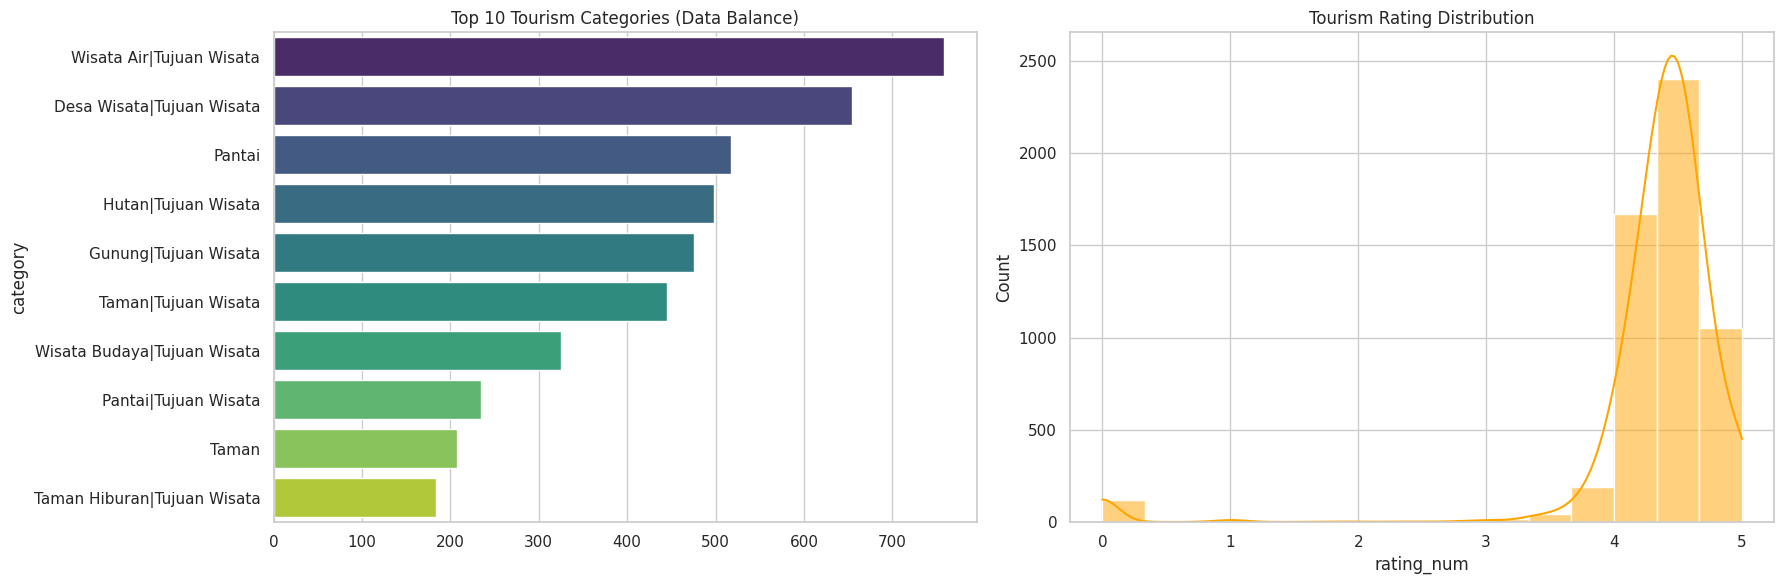

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare numeric rating data for visualization
df_eda = df.copy()
df_eda['rating_num'] = pd.to_numeric(df_eda['review_rating'], errors='coerce')

# Set style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of Top Categories
top_categories = df['category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Top 10 Tourism Categories (Data Balance)')

# 2. Rating Distribution
sns.histplot(df_eda['rating_num'].dropna(), bins=15, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Tourism Rating Distribution')

plt.tight_layout()
plt.show()

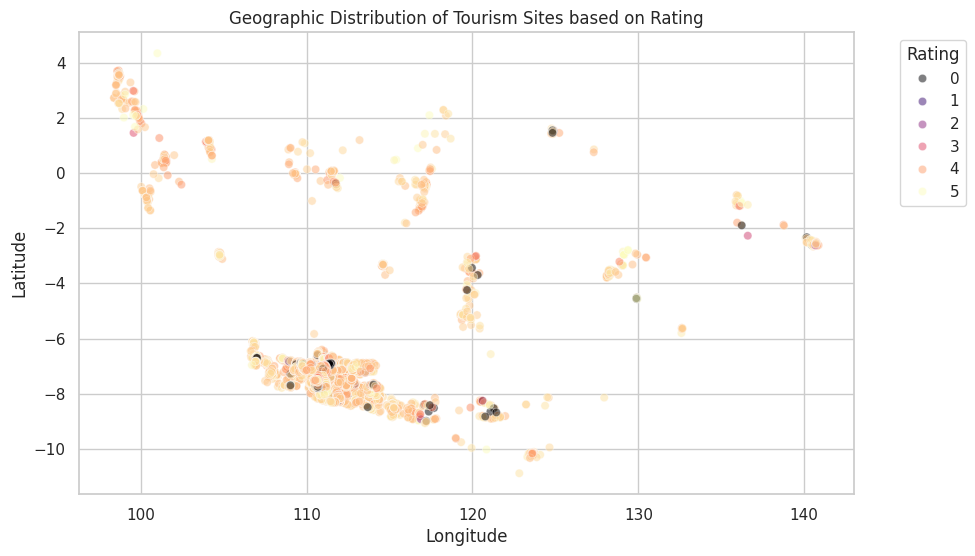

Key Statistical Summary:
Total Data: 5509
Number of Unique Categories: 90
Average Rating: 4.33


In [ ]:
# Geographic vs Rating Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='longitude', y='latitude', hue='rating_num', palette='magma', alpha=0.5)
plt.title('Geographic Distribution of Tourism Sites based on Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Key Statistical Summary for Modeling
print("Key Statistical Summary:")
print(f"Total Data: {len(df)}")
print(f"Number of Unique Categories: {df['category'].nunique()}")
print(f"Average Rating: {df_eda['rating_num'].mean():.2f}")

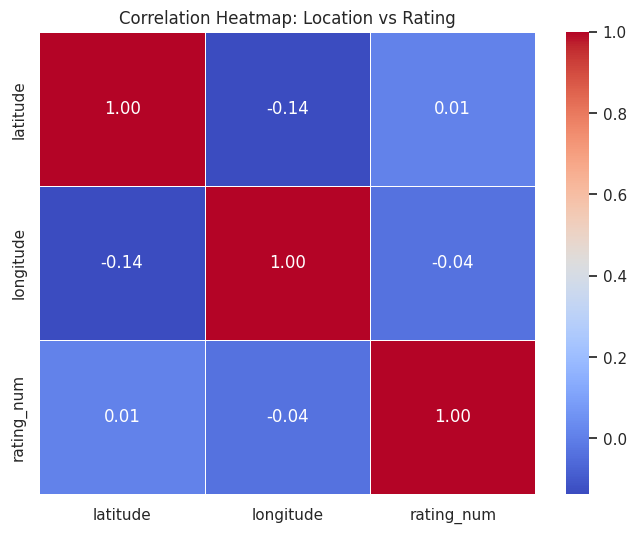

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric data is available
df_eda['rating_num'] = pd.to_numeric(df_eda['review_rating'], errors='coerce')

# Calculate correlation
corr_matrix = df_eda[['latitude', 'longitude', 'rating_num']].corr()

# Correlation Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Location vs Rating')
plt.show()

### Dimensionality Reduction Visualization (PCA vs t-SNE)
This section visualizes high-dimensional embedding data (text vectors) into 2D plots.

## 3. Model Training (Embedding Generation)
Converting descriptive text into numerical vectors using a transformer model.

In [ ]:
# MULTILINGUAL SBERT EMBEDDINGS
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print('Encoding destination text with Multilingual SBERT...')
embeddings = model.encode(df['nlp_content'].tolist(), show_progress_bar=True)
df['embeddings'] = list(embeddings)

print(f"Embedding dimension: {len(df['embeddings'].iloc[0])}")
print('Done.')


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding destination text with Multilingual SBERT...


Batches:   0%|          | 0/173 [00:00<?, ?it/s]

Embedding dimension: 384
Done.


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


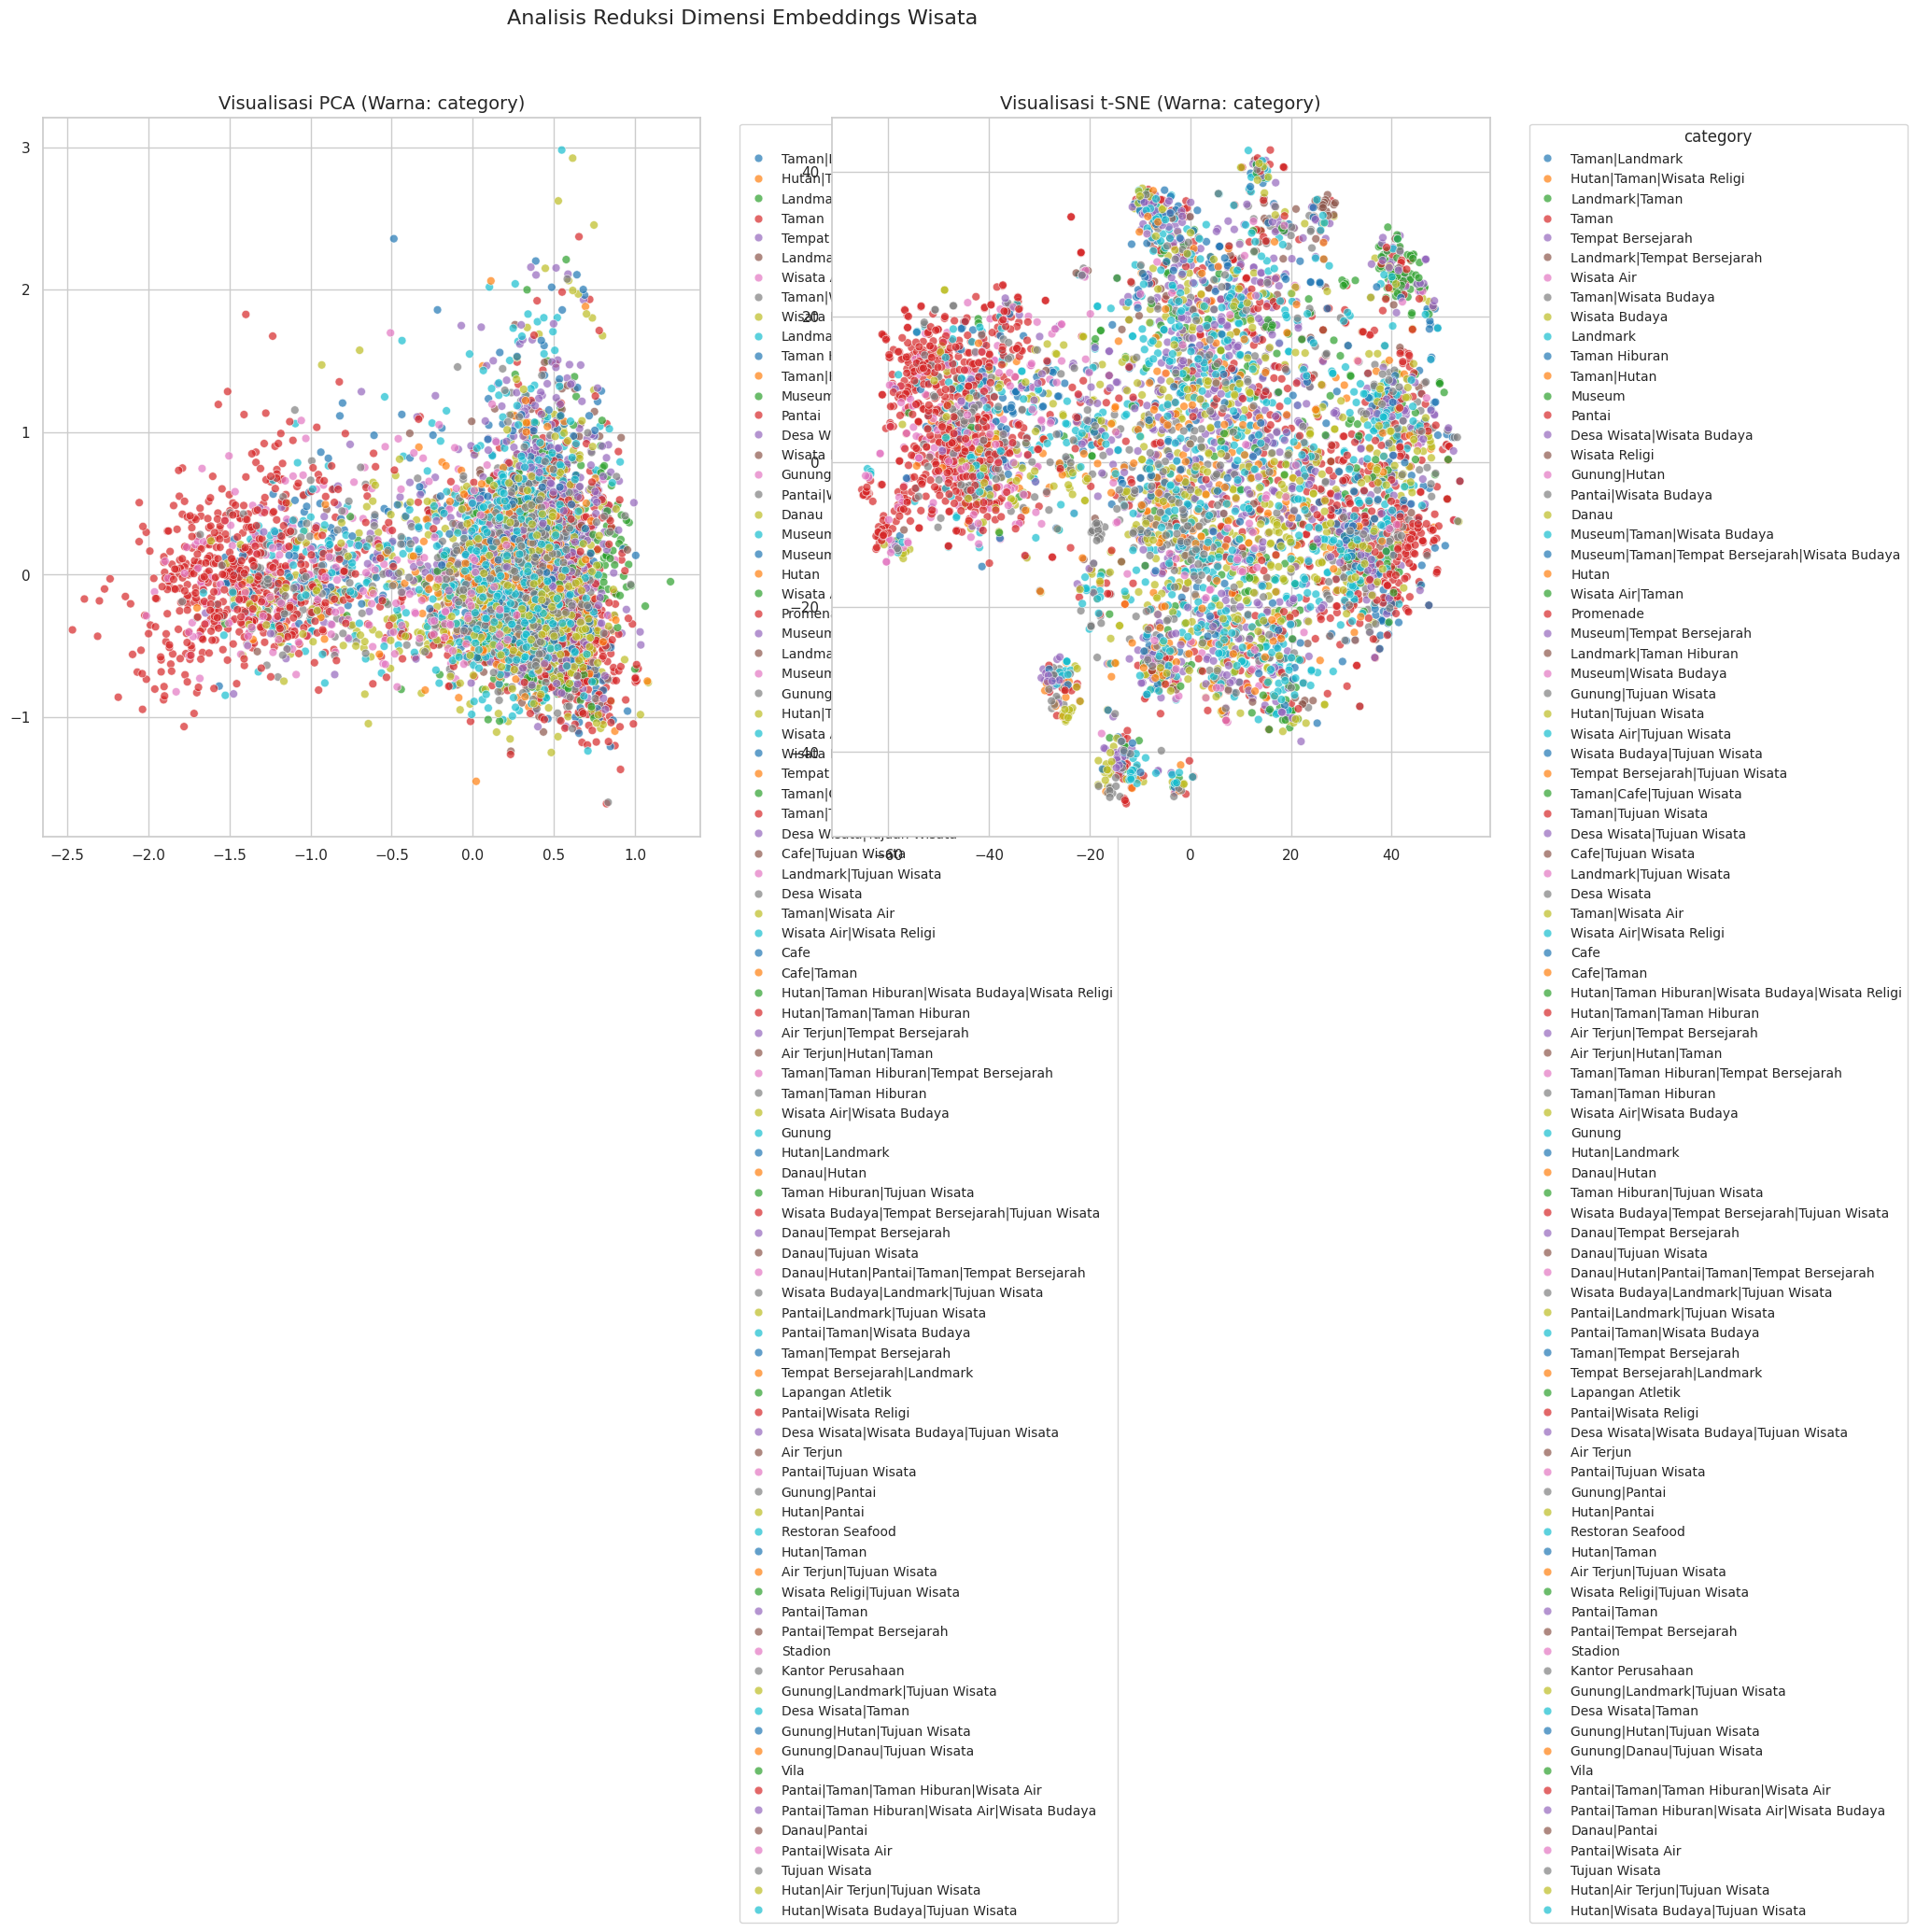

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Memastikan embeddings tersedia
X_emb = np.vstack(df['embeddings'].values)

# 1. PCA
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_emb)

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X_emb)

# Fallback ke 'category' jika 'cluster' belum dibuat
hue_col = 'cluster' if 'cluster' in df.columns else 'category'

# Perbaikan: Menggunakan constrained_layout untuk mencegah teks terpotong
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

# PCA Plot
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=df[hue_col], palette='tab10', ax=ax1, alpha=0.7, s=40)
ax1.set_title(f'Visualisasi PCA (Warna: {hue_col})', fontsize=14)
ax1.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# t-SNE Plot
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=df[hue_col], palette='tab10', ax=ax2, alpha=0.7, s=40)
ax2.set_title(f'Visualisasi t-SNE (Warna: {hue_col})', fontsize=14)
ax2.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.suptitle('Analisis Reduksi Dimensi Embeddings Wisata', fontsize=16)
plt.show()

## 4. Modeling & Evaluation
Recommendation functions and simulations to assess model performance.

In [ ]:
def get_semantic_spatial_recommendations(user_query, user_lat, user_lon, max_distance_km=30, top_n=5):
    # Auxiliary query-only mode: Multilingual-SBERT semantic ranking + Haversine filtering.
    # This is NOT the full 40:40:20 hybrid because a reference destination is not supplied.
    # 1. Convert user query into vector embeddings
    query_vec = model.encode([user_query])[0]

    # 2. Calculate NLP Cosine Similarity against all data
    embeddings_matrix = np.vstack(df['embeddings'].values)
    nlp_scores = cosine_similarity([query_vec], embeddings_matrix)[0]

    results = []

    for idx, row in df.iterrows():
        try:
            place_lat = float(row['latitude'])
            place_lon = float(row['longitude'])
        except:
            continue

        # Calculate Haversine distance
        distance_km = haversine((user_lat, user_lon), (place_lat, place_lon), unit=Unit.KILOMETERS)

        # Filter by radius
        if distance_km <= max_distance_km:
            results.append({
                'title': row['title'],
                'category': row['category'],
                'address': row.get('address', 'Alamat tidak tersedia'),
                'open_hours': row.get('open_hours', '{}'),
                'distance_km': round(distance_km, 2),
                'Score': nlp_scores[idx]
            })

    if not results:
        return pd.DataFrame()

    # Sort by highest similarity scores within the radius
    df_results = pd.DataFrame(results).sort_values(by='Score', ascending=False).head(top_n)
    return df_results


In [ ]:
def inspect_semantic_top5_similarity(n_tests=100, random_state=42):
    # Diagnostic only. Average cosine similarity is NOT recommendation accuracy.
    test_samples = df.sample(n=min(n_tests, len(df)), random_state=random_state)
    all_embeddings_local = np.vstack(df['embeddings'].values)

    mean_scores = []
    for _, row in test_samples.iterrows():
        target_idx = df.index[df['title'] == row['title']][0]
        sims = cosine_similarity([df.loc[target_idx, 'embeddings']], all_embeddings_local)[0]
        sims[target_idx] = -np.inf
        top_idx = np.argsort(sims)[-5:]
        mean_scores.append(np.mean(sims[top_idx]))

    print(
        f'Diagnostic mean Top-5 semantic cosine similarity '
        f'({len(mean_scores)} targets): {np.mean(mean_scores):.4f}'
    )
    print('This value is descriptive and is not treated as accuracy.')

inspect_semantic_top5_similarity()


Diagnostic mean Top-5 semantic cosine similarity (100 targets): 0.8171
This value is descriptive and is not treated as accuracy.


### Repeated Ranking Evaluation: Hit Rate@5 and MRR


In [ ]:
# =======================================================
# REVIEWER-ALIGNED REPEATED RANKING EVALUATION
# =======================================================

def simple_jaccard(str1, str2):
    s1 = set(re.findall(r'\w+', str(str1).lower()))
    s2 = set(re.findall(r'\w+', str(str2).lower()))
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)

all_embeddings = np.vstack(df['embeddings'].values)

def build_evaluation_frame(target_title):
    if target_title not in item_sim_df.columns:
        return None

    target_indices = df.index[df['title'] == target_title].tolist()
    if not target_indices:
        return None
    target_idx = target_indices[0]

    semantic_sim = cosine_similarity([df.loc[target_idx, 'embeddings']], all_embeddings)[0]
    meta_scores = df['title'].map(item_sim_df[target_title]).fillna(0).to_numpy(dtype=float)
    reputation_scores = np.clip(df['rating_num'].to_numpy(dtype=float) / 5.0, 0.0, 1.0)

    frame = pd.DataFrame({
        'title': df['title'].values,
        'semantic_val': semantic_sim,
        'metadata_val': meta_scores,
        'reputation_val': reputation_scores
    })

    frame = frame[frame['title'] != target_title].copy()
    frame['name_sim'] = frame['title'].apply(lambda x: simple_jaccard(x, target_title))
    frame = frame[frame['name_sim'] < 0.50].copy()
    return frame

def evaluate_weights_on_samples(test_samples, weights, top_k=5):
    w_sem, w_meta, w_rep = weights
    reciprocal_ranks = []
    hits = 0
    valid_queries = 0

    for _, row in test_samples.iterrows():
        frame = build_evaluation_frame(row['title'])
        if frame is None or frame.empty:
            continue

        valid_queries += 1
        frame['score'] = (
            w_sem * frame['semantic_val']
            + w_meta * frame['metadata_val']
            + w_rep * frame['reputation_val']
        )

        top = frame.nlargest(top_k, 'score').reset_index(drop=True)
        rr = 0.0
        for rank, rec in top.iterrows():
            is_relevant = RELEVANCE_MIN < rec['semantic_val'] < RELEVANCE_MAX
            if is_relevant:
                hits += 1
                rr = 1.0 / (rank + 1)
                break
        reciprocal_ranks.append(rr)

    if valid_queries == 0:
        return {'n_queries': 0, 'Hit Rate@5 (%)': np.nan, 'MRR': np.nan}

    return {
        'n_queries': valid_queries,
        'Hit Rate@5 (%)': 100.0 * hits / valid_queries,
        'MRR': float(np.mean(reciprocal_ranks))
    }

trial_rows = []
for seed in range(42, 47):
    test_samples = df.sample(n=min(N_EVAL_QUERIES, len(df)), random_state=seed).reset_index(drop=True)
    metrics = evaluate_weights_on_samples(test_samples, weights=(0.40, 0.40, 0.20), top_k=5)
    trial_rows.append({'Seed': seed, **metrics})

overall_eval_df = pd.DataFrame(trial_rows)
overall_summary = pd.DataFrame([{
    'Runs': len(overall_eval_df),
    'Queries per run': N_EVAL_QUERIES,
    'Mean Hit Rate@5 (%)': overall_eval_df['Hit Rate@5 (%)'].mean(),
    'SD Hit Rate@5': overall_eval_df['Hit Rate@5 (%)'].std(ddof=0),
    'Mean MRR': overall_eval_df['MRR'].mean(),
    'SD MRR': overall_eval_df['MRR'].std(ddof=0),
}])

print('=== REPEATED RANKING EVALUATION ===')
display(overall_eval_df.round(4))
print()
print('=== AGGREGATED RESULTS ===')
display(overall_summary.round(4))


=== REPEATED RANKING EVALUATION ===


,Seed,n_queries,Hit Rate@5 (%),MRR
0,42,50,94.0,0.8950
1,43,50,84.0,0.7850
2,44,50,94.0,0.9300
3,45,50,84.0,0.8200
4,46,50,98.0,0.9317



=== AGGREGATED RESULTS ===


,Runs,Queries per run,Mean Hit Rate@5 (%),SD Hit Rate@5,Mean MRR,SD MRR
0,5,50,90.8,5.7411,0.8723,0.0595


### Tourism Clustering

In [ ]:
# FUSED REPRESENTATION AND FINAL K-MEANS MODEL
all_embeddings_matrix = np.vstack(df['embeddings'].values)
X_final = np.hstack((
    all_embeddings_matrix,
    df[['scaled_lat_w', 'scaled_lon_w', 'scaled_rating_w']].to_numpy()
))

k_best = 2
kmeans_final = KMeans(
    n_clusters=k_best,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
df['cluster'] = kmeans_final.fit_predict(X_final)

print(f'K-Means fitted on the fused feature representation with K={k_best}.')
print(f'Fused matrix shape: {X_final.shape}')
print('PCA is NOT used as the training input for this final K-Means model.')


K-Means fitted on the fused feature representation with K=2.
Fused matrix shape: (5509, 387)
PCA is NOT used as the training input for this final K-Means model.


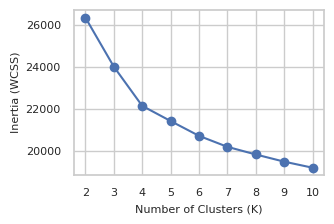

Saved reviewer-compliant vector figure: elbow_method.pdf
Interpret the elbow curve as supporting evidence only; selection of K=3 is primarily based on Silhouette and DBI diagnostics.


In [ ]:
# ELBOW DIAGNOSTIC — VECTOR PDF, ENGLISH LABELS, NO EMBEDDED TITLE
k_range = range(2, 11)
wcss = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    km.fit(X_final)
    wcss.append(km.inertia_)

plt.figure(figsize=(3.5, 2.4))
plt.plot(list(k_range), wcss, marker='o')
plt.xlabel('Number of Clusters (K)', fontsize=8)
plt.ylabel('Inertia (WCSS)', fontsize=8)
plt.xticks(list(k_range), fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('elbow_method.pdf', bbox_inches='tight')
plt.show()

print('Saved reviewer-compliant vector figure: elbow_method.pdf')
print('Interpret the elbow curve as supporting evidence only; selection of K=3 is primarily based on Silhouette and DBI diagnostics.')


### Optional visualization diagnostics

PCA and t-SNE plots below are exploratory visualizations only. They are not used as the numerical evidence reported in the manuscript. The paper's cluster-selection metrics are produced by the dedicated PCA-projected diagnostic cell above.


In [ ]:
# PCA-PROJECTED DIAGNOSTICS FOR K=2..10
pca_model = PCA(n_components=2, random_state=42)
X_pca = pca_model.fit_transform(X_final)

diagnostic_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=500, random_state=42)
    labels = km.fit_predict(X_final)
    diagnostic_rows.append({
        'K': k,
        'Silhouette_PCA': silhouette_score(X_pca, labels),
        'DBI_PCA': davies_bouldin_score(X_pca, labels)
    })

k_diag_df = pd.DataFrame(diagnostic_rows)
print('=== PCA-PROJECTED CLUSTER-SEPARATION DIAGNOSTICS ===')
display(k_diag_df.round(4))
print(f"Best Silhouette K: {int(k_diag_df.loc[k_diag_df['Silhouette_PCA'].idxmax(), 'K'])}")
print(f"Best DBI K       : {int(k_diag_df.loc[k_diag_df['DBI_PCA'].idxmin(), 'K'])}")


=== PCA-PROJECTED CLUSTER-SEPARATION DIAGNOSTICS ===


,K,Silhouette_PCA,DBI_PCA
0,2,0.7049,0.6802
1,3,0.6974,0.7657
2,4,0.4804,0.8623
3,5,0.4891,0.8363
4,6,0.1218,5.2283
5,7,0.0994,3.2701
6,8,0.0880,3.8065
7,9,0.0897,3.9029
8,10,0.0698,6.6216


Best Silhouette K: 2
Best DBI K       : 2


### Direct clustering-algorithm comparison

This diagnostic compares K-Means, Hierarchical clustering, and DBSCAN on the **same fused 387-dimensional representation** and the **same deterministic sample**. DBSCAN metrics are computed only on non-noise observations, and the noise proportion is reported separately.


In [ ]:
# DETERMINISTIC SAME-SPACE CLUSTERING COMPARISON
sample_size = min(2000, len(X_final))
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(len(X_final), size=sample_size, replace=False))
X_cluster_sample = X_final[sample_idx]

comparison_rows = []

km = KMeans(n_clusters=2, n_init=20, max_iter=500, random_state=42)
labels_km = km.fit_predict(X_cluster_sample)
comparison_rows.append({
    'Algorithm': 'K-Means (K=2)',
    'Evaluated observations': len(X_cluster_sample),
    'Noise (%)': 0.0,
    'Silhouette': silhouette_score(X_cluster_sample, labels_km),
    'DBI': davies_bouldin_score(X_cluster_sample, labels_km)
})

hc = AgglomerativeClustering(n_clusters=2)
labels_hc = hc.fit_predict(X_cluster_sample)
comparison_rows.append({
    'Algorithm': 'Hierarchical (K=2)',
    'Evaluated observations': len(X_cluster_sample),
    'Noise (%)': 0.0,
    'Silhouette': silhouette_score(X_cluster_sample, labels_hc),
    'DBI': davies_bouldin_score(X_cluster_sample, labels_hc)
})

db = DBSCAN(eps=2.5, min_samples=5)
labels_db = db.fit_predict(X_cluster_sample)
non_noise = labels_db != -1
noise_pct = 100.0 * np.mean(labels_db == -1)
unique_non_noise_clusters = np.unique(labels_db[non_noise])

if non_noise.sum() > 1 and len(unique_non_noise_clusters) > 1:
    db_sil = silhouette_score(X_cluster_sample[non_noise], labels_db[non_noise])
    db_dbi = davies_bouldin_score(X_cluster_sample[non_noise], labels_db[non_noise])
else:
    db_sil = np.nan
    db_dbi = np.nan

comparison_rows.append({
    'Algorithm': 'DBSCAN (eps=2.5)',
    'Evaluated observations': int(non_noise.sum()),
    'Noise (%)': noise_pct,
    'Silhouette': db_sil,
    'DBI': db_dbi
})

cluster_algo_df = pd.DataFrame(comparison_rows)
print('=== DIRECT CLUSTERING COMPARISON ON SAME FUSED FEATURE SPACE ===')
display(cluster_algo_df.round(4))
cluster_algo_df.to_csv('clustering_algorithm_comparison.csv', index=False)


=== DIRECT CLUSTERING COMPARISON ON SAME FUSED FEATURE SPACE ===


,Algorithm,Evaluated observations,Noise (%),Silhouette,DBI
0,K-Means (K=2),2000,0.00,0.3427,1.4802
1,Hierarchical (K=2),2000,0.00,0.3301,1.5678
2,DBSCAN (eps=2.5),1957,2.15,NaN,NaN


### 4.2.1 DBSCAN Hyperparameter Tuning
To determine the optimal `eps` value, we calculate the average distance of each point to its k-nearest neighbors. The point where a sharp increase occurs (the elbow) is the suggested `eps` value.

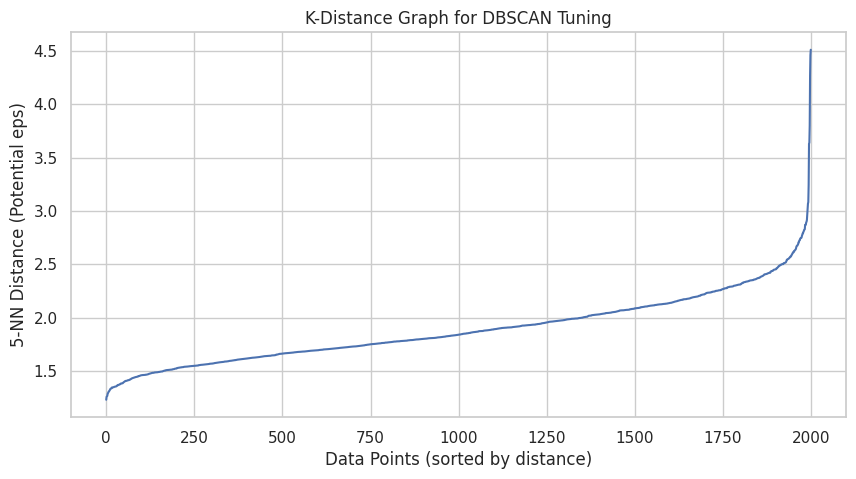

Inspect the region where the k-distance curve begins to increase sharply.
This is an exploratory diagnostic only and is not used as manuscript evidence.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Optional DBSCAN diagnostic on the same deterministic fused-feature sample.
# We keep min_samples=5 for comparability with the direct clustering comparison.
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cluster_sample)
distances, indices = neighbors_fit.kneighbors(X_cluster_sample)

# 2. Urutkan jarak dari yang terkecil ke terbesar
sorted_distances = np.sort(distances[:, min_samples-1], axis=0)

# 3. Visualisasi K-Distance Graph
plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.title('K-Distance Graph for DBSCAN Tuning')
plt.xlabel('Data Points (sorted by distance)')
plt.ylabel(f'{min_samples}-NN Distance (Potential eps)')
plt.grid(True)
plt.show()

print("Inspect the region where the k-distance curve begins to increase sharply.")
print("This is an exploratory diagnostic only and is not used as manuscript evidence.")


### 4.2.2 Executing DBSCAN with Optimal Parameters
Based on the graph, we run DBSCAN with a looser `eps` value to ensure data is not incorrectly categorized as noise.

In [ ]:
# Mencoba beberapa nilai eps berdasarkan estimasi k-distance graph
eps_candidates = [1.5, 2.5, 4.0]

tuning_results = []

for e in eps_candidates:
    db_tuned = DBSCAN(eps=e, min_samples=5)
    labels_tuned = db_tuned.fit_predict(X_cluster_sample)

    n_clusters = len(set(labels_tuned)) - (1 if -1 in labels_tuned else 0)
    n_noise = list(labels_tuned).count(-1)

    if n_clusters > 1:
        tuning_results.append({
            'Eps': e,
            'Clusters Found': n_clusters,
            'Noise Points': n_noise,
            'Silhouette': silhouette_score(X_cluster_sample, labels_tuned),
            'DBI': davies_bouldin_score(X_cluster_sample, labels_tuned)
        })

if tuning_results:
    print("=== OPTIONAL DBSCAN TUNING RESULTS ===")
    display(pd.DataFrame(tuning_results))
else:
    print("No stable multi-cluster DBSCAN solution was found for these exploratory eps values.")


=== OPTIONAL DBSCAN TUNING RESULTS ===


,Eps,Clusters Found,Noise Points,Silhouette,DBI
0,1.5,5,1643,-0.21529,2.981509


### TF-IDF vs Multilingual SBERT on the same evaluation queries


In [ ]:
# TEXT REPRESENTATION COMPARISON USING THE SAME 50 TARGET QUERIES
# The common relevance proxy still uses Multilingual-SBERT semantic similarity,
# so this comparison is diagnostic and may favor semantic ranking.

tfidf_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['nlp_content'].fillna(''))

fixed_text_test_samples = df.sample(n=min(N_EVAL_QUERIES, len(df)), random_state=42).reset_index(drop=True)

def evaluate_text_ranker(method_name):
    hits = 0
    reciprocal_ranks = []
    valid_queries = 0

    for _, row in fixed_text_test_samples.iterrows():
        target_title = row['title']
        target_indices = df.index[df['title'] == target_title].tolist()
        if not target_indices:
            continue
        target_idx = target_indices[0]

        semantic_gt = cosine_similarity([df.loc[target_idx, 'embeddings']], all_embeddings)[0]

        if method_name == 'Multilingual SBERT':
            ranking_scores = semantic_gt.copy()
        elif method_name == 'TF-IDF':
            ranking_scores = cosine_similarity(tfidf_matrix[target_idx], tfidf_matrix).ravel()
        else:
            raise ValueError(method_name)

        frame = pd.DataFrame({
            'title': df['title'].values,
            'semantic_gt': semantic_gt,
            'ranking_score': ranking_scores
        })
        frame = frame[frame['title'] != target_title].copy()
        frame['name_sim'] = frame['title'].apply(lambda x: simple_jaccard(x, target_title))
        frame = frame[frame['name_sim'] < 0.50].copy()
        if frame.empty:
            continue

        valid_queries += 1
        top = frame.nlargest(5, 'ranking_score').reset_index(drop=True)
        rr = 0.0
        for rank, rec in top.iterrows():
            if RELEVANCE_MIN < rec['semantic_gt'] < RELEVANCE_MAX:
                hits += 1
                rr = 1.0 / (rank + 1)
                break
        reciprocal_ranks.append(rr)

    return {
        'Method': method_name,
        'Queries': valid_queries,
        'Hit Rate@5 (%)': 100.0 * hits / valid_queries if valid_queries else np.nan,
        'MRR': float(np.mean(reciprocal_ranks)) if reciprocal_ranks else np.nan
    }

text_method_eval_df = pd.DataFrame([
    evaluate_text_ranker('TF-IDF'),
    evaluate_text_ranker('Multilingual SBERT')
])

print('=== TF-IDF VS MULTILINGUAL SBERT: SAME QUERIES, SAME RELEVANCE PROXY ===')
display(text_method_eval_df.round(4))
text_method_eval_df.to_csv('text_representation_comparison.csv', index=False)


=== TF-IDF VS MULTILINGUAL SBERT: SAME QUERIES, SAME RELEVANCE PROXY ===


,Method,Queries,Hit Rate@5 (%),MRR
0,TF-IDF,50,76.0,0.608
1,Multilingual SBERT,50,96.0,0.960


In [ ]:
print('=== CLUSTERING COMPARISON (DETERMINISTIC, SAME FUSED SPACE) ===')
display(cluster_algo_df.round(4))
print()
print('Interpretation:')
print('- K-Means and Hierarchical assign every sampled destination to a cluster.')
print('- DBSCAN may mark sparse observations as noise.')
print('- Do not mix these direct fused-space metrics with PCA-projected K-selection diagnostics.')


=== CLUSTERING COMPARISON (DETERMINISTIC, SAME FUSED SPACE) ===


,Algorithm,Evaluated observations,Noise (%),Silhouette,DBI
0,K-Means (K=2),2000,0.00,0.3427,1.4802
1,Hierarchical (K=2),2000,0.00,0.3301,1.5678
2,DBSCAN (eps=2.5),1957,2.15,NaN,NaN



Interpretation:
- K-Means and Hierarchical assign every sampled destination to a cluster.
- DBSCAN may mark sparse observations as noise.
- Do not mix these direct fused-space metrics with PCA-projected K-selection diagnostics.


### Comprehensive Comparison (K=2 to K=10)
This cell compares K-Means and Hierarchical Clustering across various K values to provide stronger empirical evidence for your paper.

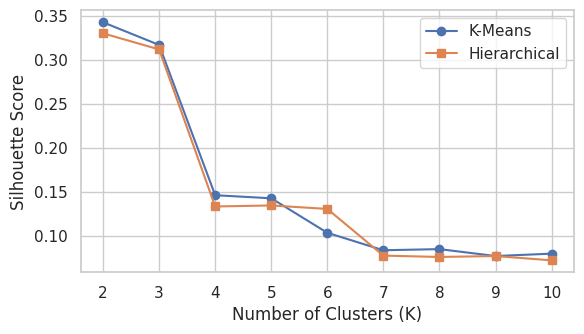

In [ ]:
# OPTIONAL DETERMINISTIC SILHOUETTE CURVE COMPARISON
# This plot is exploratory and is not used as a manuscript table.
comparison_sample_size = min(2000, len(X_final))
comparison_rng = np.random.default_rng(42)
comparison_idx = np.sort(comparison_rng.choice(len(X_final), size=comparison_sample_size, replace=False))
X_optional_sample = X_final[comparison_idx]

km_sil, hc_sil = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_optional_sample)
    hc = AgglomerativeClustering(n_clusters=k).fit(X_optional_sample)
    km_sil.append(silhouette_score(X_optional_sample, km.labels_))
    hc_sil.append(silhouette_score(X_optional_sample, hc.labels_))

plt.figure(figsize=(6, 3.5))
plt.plot(range(2, 11), km_sil, marker='o', label='K-Means')
plt.plot(range(2, 11), hc_sil, marker='s', label='Hierarchical')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()


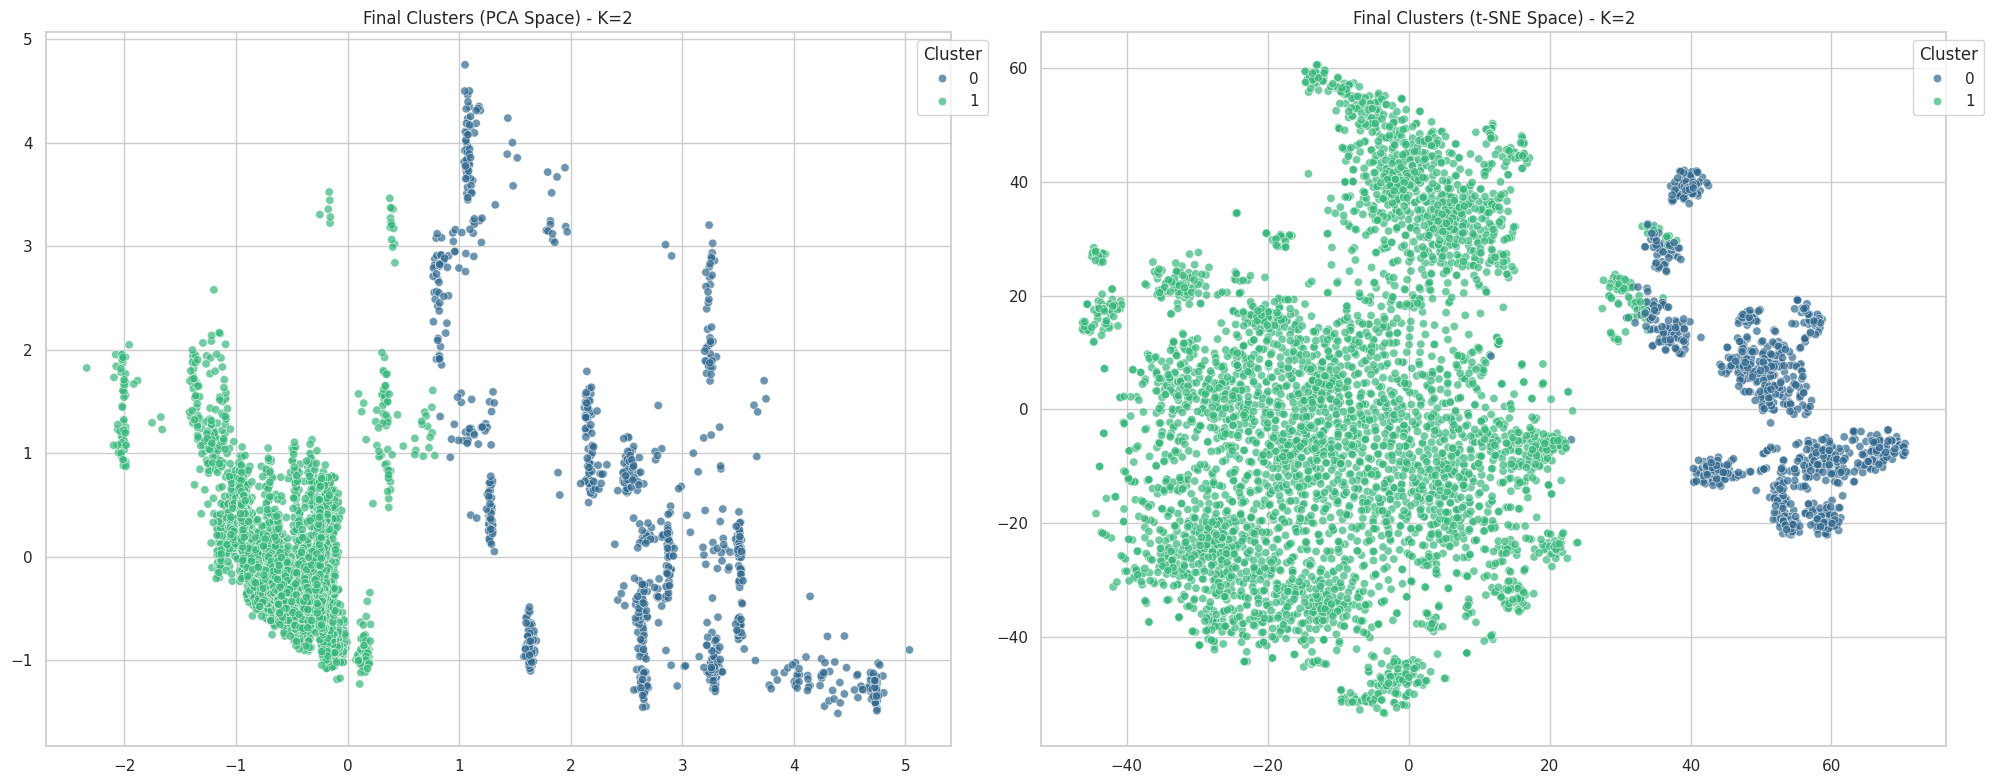

In [ ]:
# 4. VISUALISASI FINAL CLUSTERS (Sesuai Elbow Method)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

k_best = 2

# Visualisasi menggunakan fitur yang sudah digabung (X_final)
pca_final = PCA(n_components=2, random_state=42).fit_transform(X_final)
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_final)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot PCA
sns.scatterplot(x=pca_final[:, 0], y=pca_final[:, 1], hue=df['cluster'], palette='viridis', ax=ax1, alpha=0.7)
ax1.set_title(f'Final Clusters (PCA Space) - K={k_best}')
ax1.legend(title='Cluster', bbox_to_anchor=(1.05, 1))

# Plot t-SNE
sns.scatterplot(x=tsne_final[:, 0], y=tsne_final[:, 1], hue=df['cluster'], palette='viridis', ax=ax2, alpha=0.7)
ax2.set_title(f'Final Clusters (t-SNE Space) - K={k_best}')
ax2.legend(title='Cluster', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


### Cluster inspection without unsupported thematic labels


In [ ]:
cluster_summary_rows = []
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id].copy()
    examples = cluster_data['title'].head(3).tolist()
    cluster_summary_rows.append({
        'Cluster': int(cluster_id),
        'Size': len(cluster_data),
        'Mean latitude': cluster_data['latitude'].mean(),
        'Mean longitude': cluster_data['longitude'].mean(),
        'Representative destinations': ' | '.join(examples)
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows)
print('=== CLUSTER STRUCTURAL SUMMARY ===')
display(cluster_summary_df.round({'Mean latitude': 4, 'Mean longitude': 4}))
print()
print('Report these as structural groups in the fused feature space. Do not assign tourism-theme labels without a validated labeling procedure.')


=== CLUSTER STRUCTURAL SUMMARY ===


,Cluster,Size,Mean latitude,Mean longitude,Representative destinations
0,0,977,-0.6495,112.2971,The Le Hu Garden | TAMAN WISATA DANAU SIOMBAK ...
1,1,4532,-7.4602,111.7167,Alun - Alun Surabaya | Hutan Bambu Keputih Sur...



Report these as structural groups in the fused feature space. Do not assign tourism-theme labels without a validated labeling procedure.


In [ ]:
# Uji Coba
# Contoh: User mencari 'wisata sejarah' dan dia sebelumnya menyukai 'Monumen Nasional'
query = "wisata sejarah yang edukatif"
target = "Monumen Nasional"

print(f"--- Rekomendasi Hybrid ---")
print(f"Query: {query}")
print(f"Berdasarkan Kesukaan pada: {target}\n")

hasil_super = get_super_hybrid_recommendations(user_query=query, target_place_title=target, top_n=5)
display(hasil_super)

--- Rekomendasi Hybrid ---
Query: wisata sejarah yang edukatif
Berdasarkan Kesukaan pada: Monumen Nasional



,title,category,semantic_score,metadata_score,reputation_score,final_score
375,Keraton Ngayogyakarta Hadiningrat,Wisata Budaya|Tempat Bersejarah|Tujuan Wisata,0.553246,0.930261,0.94,0.781402
390,Museum Sonobudoyo Unit I,Wisata Budaya|Tempat Bersejarah|Tujuan Wisata,0.535808,0.908108,0.96,0.769567
27,Monumen Tugu Pahlawan dan Museum Sepuluh Nopem...,Museum,0.501761,0.950915,0.94,0.769070
135,Museum Kebangkitan Nasional,Museum|Tempat Bersejarah,0.578246,0.867058,0.94,0.766122
898,Monumen Bajra Sandhi,Landmark|Tempat Bersejarah,0.483471,0.943746,0.92,0.754887


In [ ]:
# Test Run
query = "educational historical tourism"
target = "Monumen Nasional"

print(f"--- Hybrid Recommendation Results ---")
print(f"Query: {query}")
print(f"Based on Liked Place: {target}\n")

try:
    hasil_super = get_super_hybrid_recommendations(user_query=query, target_place_title=target, top_n=5)
    display(hasil_super)
except Exception as e:
    print(f"An error occurred: {e}")

--- Hybrid Recommendation Results ---
Query: educational historical tourism
Based on Liked Place: Monumen Nasional



,title,category,semantic_score,metadata_score,reputation_score,final_score
375,Keraton Ngayogyakarta Hadiningrat,Wisata Budaya|Tempat Bersejarah|Tujuan Wisata,0.519279,0.930261,0.94,0.767816
27,Monumen Tugu Pahlawan dan Museum Sepuluh Nopem...,Museum,0.483963,0.950915,0.94,0.761951
390,Museum Sonobudoyo Unit I,Wisata Budaya|Tempat Bersejarah|Tujuan Wisata,0.509754,0.908108,0.96,0.759145
147,Museum Mandiri,Museum,0.459546,0.928240,0.94,0.743114
135,Museum Kebangkitan Nasional,Museum|Tempat Bersejarah,0.516591,0.867058,0.94,0.741460


### Baseline and weight-sensitivity analysis

This experiment uses one fixed set of 50 target destinations (`random_state=42`) so that all weight configurations are compared on identical queries.


In [ ]:
scenarios = {
    'Pure Semantic': (1.00, 0.00, 0.00),
    'Pure Metadata Affinity': (0.00, 1.00, 0.00),
    'Alternative Hybrid (50:30:20)': (0.50, 0.30, 0.20),
    'Proposed Balanced Hybrid (40:40:20)': (0.40, 0.40, 0.20),
}

fixed_test_samples = df.sample(n=min(N_EVAL_QUERIES, len(df)), random_state=42).reset_index(drop=True)
sensitivity_rows = []

for scenario_name, weights in scenarios.items():
    metrics = evaluate_weights_on_samples(fixed_test_samples, weights=weights, top_k=5)
    sensitivity_rows.append({
        'Scenario': scenario_name,
        'Weights': f'{weights[0]:.2f}:{weights[1]:.2f}:{weights[2]:.2f}',
        **metrics
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print('=== FIXED-SAMPLE BASELINE AND WEIGHT-SENSITIVITY ANALYSIS ===')
display(sensitivity_df.round(4))
sensitivity_df.to_csv('weight_sensitivity_results.csv', index=False)
print()
print('Do not describe 40:40:20 as empirically optimal if another configuration matches or exceeds its retrieval metrics.')


=== FIXED-SAMPLE BASELINE AND WEIGHT-SENSITIVITY ANALYSIS ===


,Scenario,Weights,n_queries,Hit Rate@5 (%),MRR
0,Pure Semantic,1.00:0.00:0.00,50,96.0,0.9600
1,Pure Metadata Affinity,0.00:1.00:0.00,50,60.0,0.3493
2,Alternative Hybrid (50:30:20),0.50:0.30:0.20,50,96.0,0.9400
3,Proposed Balanced Hybrid (40:40:20),0.40:0.40:0.20,50,94.0,0.8950



Do not describe 40:40:20 as empirically optimal if another configuration matches or exceeds its retrieval metrics.


## 5. Form User

In [ ]:
import json
import numpy as np
import ast

# --- USER FORM ---
Tourism_Criteria = "flower garden" # @param {type:"string"}
Favorite_Place_Name = "" # @param {type:"string"}
User_Latitude = -6.1754 # @param {type:"number"}
User_Longitude = 106.8272 # @param {type:"number"}
Radius_KM = 50 # @param {type:"slider", min:5, max:1000, step:5}

print("="*50)
print(f"SEARCHING RECOMMENDATIONS (MAX {Radius_KM} KM)")
print("="*50 + "\n")

def get_recommendations_logic(query, target, lat, lon, radius):
    target = target.strip()
    if target != "":
        if target not in item_sim_df.columns:
            return f"Sorry, place '{target}' was not found in the database."
        return get_hybrid_recommendations(target, user_lat=lat, user_lon=lon, max_distance_km=radius)
    else:
        print('Mode: semantic-spatial query only (not the full 40:40:20 hybrid).')
        return get_semantic_spatial_recommendations(query, lat, lon, max_distance_km=radius)

results = get_recommendations_logic(Tourism_Criteria, Favorite_Place_Name, User_Latitude, User_Longitude, Radius_KM)

if isinstance(results, str):
    print(f"Message: {results}")
elif results.empty:
    print("Message: No places found within that radius.")
else:
    day_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

    for i, (idx, row) in enumerate(results.iterrows()):
        title_key = 'title'
        full_data = df[df['title'] == row[title_key]].iloc[0]

        print(f"{i+1}. PLACE NAME: {full_data['title'].upper()}")
        print(f"   Category   : {full_data['category']}")
        print(f"   Address    : {full_data.get('address', 'N/A')}")

        # Tampilan Fasilitas dalam bentuk list
        print(f"   Facilities :")
        facilities_raw = full_data.get('clean_about', '')
        if not facilities_raw or pd.isna(facilities_raw):
            print("      - Informasi tidak tersedia")
        else:
            fac_list = [f.strip() for f in facilities_raw.split(',') if f.strip()]
            for fac in fac_list:
                print(f"      - {fac}")

        print(f"   Distance   : {row['distance_km']} km")
        print(f"   Rating     : {full_data['review_rating']} / 5.0")

        # Parsing Jam Operasional
        print(f"   Operating Hours:")
        try:
            hours_raw = full_data['open_hours']
            if pd.isna(hours_raw) or hours_raw == "" or hours_raw == '{}':
                print("      Jadwal tidak tersedia")
            else:
                try:
                    hours_dict = json.loads(hours_raw)
                except:
                    hours_dict = ast.literal_eval(hours_raw)

                for day in day_order:
                    time = hours_dict.get(day, ["Tutup"])
                    print(f"      - {day}: {', '.join(time) if isinstance(time, list) else time}")
        except:
            print("      Gagal memuat jadwal")

        print(f"   Match Score: {round(row.get('final_hybrid_score', row.get('Score', 0)), 4)}")
        print("-"*50)


SEARCHING RECOMMENDATIONS (MAX 50 KM)

Mode: semantic-spatial query only (not the full 40:40:20 hybrid).
1. PLACE NAME: TAMAN ANGGREK INDONESIA PERMAI
   Category   : Taman
   Address    : Jl. Taman Mini I No.I, RT.4/RW.2, Pinang Ranti, Kec. Cipayung, Kota Jakarta Timur, Daerah Khusus Ibukota Jakarta 13560, Indonesia
   Facilities :
      - Layanan di tempat
      - Pintu masuk khusus pengguna kursi roda
      - Tempat parkir khusus pengguna kursi roda
   Distance   : 14.39 km
   Rating     : 4.6 / 5.0
   Operating Hours:
      - Senin: 09.00–17.00
      - Selasa: 09.00–17.00
      - Rabu: 09.00–17.00
      - Kamis: 09.00–17.00
      - Jumat: 09.00–17.00
      - Sabtu: 09.00–17.00
      - Minggu: 09.00–17.00
   Match Score: 0.4842
--------------------------------------------------
2. PLACE NAME: GRIYA ANGGREK KEBON RAYA BOGOR
   Category   : Wisata Air|Tujuan Wisata
   Address    : CR33+R5P Griya Anggrek Kebon Raya Bogor, Jl. Kebun Raya Bogor, RT.04/RW.02, Paledang, Kecamatan Bogor Ten

## Final paper-ready outputs

After **Runtime → Run all**, use the following final cell to update the LaTeX manuscript. The manuscript must not be uploaded while any `TBD` placeholder remains.


In [ ]:
print('========== VALUES TO COPY INTO THE PAPER ==========')
print()
print('[1] DATA CLEANING')
print(f'Raw rows: {raw_count}')
print(f'Duplicate-title rows removed: {duplicate_title_rows_removed}')
print(f'Coordinate-missing rows removed: {coordinate_rows_removed}')
print(f'Final rows: {len(df)}')
print(f'Missing/invalid ratings imputed: {n_missing_rating}')
print(f'Rating imputation value: {rating_imputation_value:.2f}')

print()
print('[2] TABLE I — ROBUST-SCALED STATISTICS')
display(paper_stats)
print()
print('[3] TABLE II — PCA-PROJECTED K DIAGNOSTICS')
display(k_diag_df.round(4))
print()
print('[4] TABLE IV — TF-IDF VS MULTILINGUAL SBERT')
display(text_method_eval_df.round(4))
print()
print('[5] DIRECT CLUSTERING COMPARISON (K=2; SAME FUSED SPACE)')
display(cluster_algo_df.round(4))
print()
print('[6] TABLE VI — BASELINE / WEIGHT SENSITIVITY')
display(sensitivity_df.round(4))
print()
print('[7] TABLE VII — FIVE-RUN OVERALL EVALUATION')
display(overall_eval_df.round(4))
display(overall_summary.round(4))
print()
print('[8] FILES EXPORTED FOR PAPER')
print('- elbow_method.pdf')
print('- text_representation_comparison.csv')
print('- clustering_algorithm_comparison.csv')
print('- weight_sensitivity_results.csv')


========== VALUES TO COPY INTO THE PAPER ==========

[1] DATA CLEANING
Raw rows: 5618
Duplicate-title rows removed: 109
Coordinate-missing rows removed: 0
Final rows: 5509
Missing/invalid ratings imputed: 117
Rating imputation value: 4.50

[2] TABLE I — ROBUST-SCALED STATISTICS


,robust_scaled_latitude,robust_scaled_longitude,robust_scaled_rating_num
mean,0.888,0.153,-0.262
std,2.582,1.652,1.095
min,-3.360,-3.691,-11.667
25%,-0.517,-0.523,-0.667
50%,0.000,0.000,0.000
75%,0.483,0.477,0.333
max,10.602,8.463,1.667



[3] TABLE II — PCA-PROJECTED K DIAGNOSTICS


,K,Silhouette_PCA,DBI_PCA
0,2,0.7049,0.6802
1,3,0.6974,0.7657
2,4,0.4804,0.8623
3,5,0.4891,0.8363
4,6,0.1218,5.2283
5,7,0.0994,3.2701
6,8,0.0880,3.8065
7,9,0.0897,3.9029
8,10,0.0698,6.6216



[4] TABLE IV — TF-IDF VS MULTILINGUAL SBERT


...

,Scenario,Weights,n_queries,Hit Rate@5 (%),MRR
0,Pure Semantic,1.00:0.00:0.00,50,96.0,0.9600
1,Pure Metadata Affinity,0.00:1.00:0.00,50,60.0,0.3493
2,Alternative Hybrid (50:30:20),0.50:0.30:0.20,50,96.0,0.9400
3,Proposed Balanced Hybrid (40:40:20),0.40:0.40:0.20,50,94.0,0.8950



[7] TABLE VII — FIVE-RUN OVERALL EVALUATION


,Seed,n_queries,Hit Rate@5 (%),MRR
0,42,50,94.0,0.8950
1,43,50,84.0,0.7850
2,44,50,94.0,0.9300
3,45,50,84.0,0.8200
4,46,50,98.0,0.9317


,Runs,Queries per run,Mean Hit Rate@5 (%),SD Hit Rate@5,Mean MRR,SD MRR
0,5,50,90.8,5.7411,0.8723,0.0595



[8] FILES EXPORTED FOR PAPER
- elbow_method.pdf
- text_representation_comparison.csv
- clustering_algorithm_comparison.csv
- weight_sensitivity_results.csv
